# Pruebas para los modelos 80-20 y 90-10

In [23]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. CARGA DE DATOS Y CONFIGURACIÓN
# =====================================================================
ruta_bd = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_semanal_meteo_epi_2022-2025.xlsx"

df_original = pd.read_excel(ruta_bd)

# --- CONFIGURACIÓN DE COLUMNAS ---
col_dengue = 'casos_dengue'
col_hum = 'hum_esp'
col_temp = 'temp_max'
col_prec = 'prec'
col_lluvia = 'dias_lluvia'
col_sst = 'sst'
col_soi = 'soi'

# Creamos copia para trabajar
df = df_original[[col_dengue]].copy()

# Generamos los rezagos (lags) especificados
df['hum_esp_lag6'] = df_original[col_hum].shift(6)
df['temp_max_lag4'] = df_original[col_temp].shift(4)
df['prec_lag7'] = df_original[col_prec].shift(7)
df['lluvia_lag3'] = df_original[col_lluvia].shift(3)
df['sst_lag10'] = df_original[col_sst].shift(10)
df['soi_lag8'] = df_original[col_soi].shift(8)

# Limpieza de filas vacías debido a los rezagos
df = df.dropna().reset_index(drop=True)

# --- APLICACIÓN DE LOGARITMO A LA VARIABLE OBJETIVO ---
# Guardamos la serie original para evaluar las métricas reales al final
y_original = df[col_dengue].values
# Aplicamos log(x + 1)
df['log_casos'] = np.log1p(df[col_dengue])

# Definimos las variables de trabajo (y modificada, X original sin escalar aún)
y_log = df['log_casos']
X_raw = df[['hum_esp_lag6', 'temp_max_lag4', 'prec_lag7', 'lluvia_lag3', 'sst_lag10', 'soi_lag8']]

print(f"Datos procesados (2022-2025): {len(df)} semanas disponibles.")

# --- FUNCIONES DE MÉTRICAS AVANZADAS ---
def calcular_wape(reales, predichos):
    return np.sum(np.abs(reales - predichos)) / np.sum(reales)

def calcular_maape(reales, predichos):
    # Epsilon extremadamente pequeño para evitar divisiones indeterminadas por cero
    eps = 1e-9
    division = np.abs((reales - predichos) / (reales + eps))
    # Retorna el promedio del arco tangente del error relativo
    return np.mean(np.arctan(division))

resultados_globales = []



Datos procesados (2022-2025): 199 semanas disponibles.


In [24]:
# =====================================================================
# 2. EJECUCIÓN DE ESCENARIOS (80-20 y 90-10) WITH ROLLING FORECAST
# =====================================================================
escenarios = {
    "Escenario 80-20": 0.80,
    "Escenario 90-10": 0.90
}

for nombre_escenario, porcentaje in escenarios.items():
    split_point = int(len(df) * porcentaje)
    
    for tipo_modelo in ['ARIMA', 'ARIMAX']:
        predicciones_log_test = []
        valores_reales_test = []
        primer_modelo_entrenado = None
        primer_scaler = None
        
        # Bucle de Rolling Forecast con Ventana Expandida (Paso = 1 semana)
        for t in range(split_point, len(df)):
            # Partición del set de entrenamiento indexado en logaritmo
            y_train_log = y_log.iloc[:t]
            y_test_real = y_original[t] # Guardamos el real (sin log) para validar
            
            if tipo_modelo == 'ARIMA':
                model = ARIMA(y_train_log, order=(1, 1, 1))
                model_fit = model.fit()
                forecast_log = model_fit.forecast(steps=1)
            else:
                # --- ESCALAMIENTO DENTRO DEL BUCLE (Previene Data Leakage) ---
                X_train_raw = X_raw.iloc[:t]
                X_test_raw = X_raw.iloc[t:t+1]
                
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_raw)
                X_test_scaled = scaler.transform(X_test_raw)
                
                model = ARIMA(y_train_log, exog=X_train_scaled, order=(1, 1, 1))
                model_fit = model.fit()
                forecast_log = model_fit.forecast(steps=1, exog=X_test_scaled)
                
                if t == split_point:
                    primer_scaler = scaler
            
            if t == split_point:
                primer_modelo_entrenado = model_fit
                
            # Guardamos la predicción que aún está en escala logarítmica
            predicciones_log_test.append(forecast_log.iloc[0])
            valores_reales_test.append(y_test_real)
            
        # --- DESTRANSFORMACIÓN DE PREDICCIONES DE TESTEO ---
        predicciones_log_test = np.array(predicciones_log_test)
        valores_reales_test = np.array(valores_reales_test)
        # Aplicamos la función exponencial inversa: exp(x) - 1
        predicciones_reales_test = np.expm1(predicciones_log_test)
        
        # --- CÁLCULO DE MÉTRICAS ---
        # 1. Entrenamiento (In-Sample del primer corte)
        # Reconstruimos valores predichos en entrenamiento pasados a escala real
        y_train_pred_log = primer_modelo_entrenado.fittedvalues
        y_train_pred_real = np.expm1(y_train_pred_log)
        y_train_real_real = y_original[:split_point]
        
        mae_train = mean_absolute_error(y_train_real_real, y_train_pred_real)
        rmse_train = root_mean_squared_error(y_train_real_real, y_train_pred_real)
        wape_train = calcular_wape(y_train_real_real, y_train_pred_real)
        maape_train = calcular_maape(y_train_real_real, y_train_pred_real)
        
        # AIC y BIC se extraen directo del modelo (evalúan la verosimilitud en la escala entrenada)
        aic_train = primer_modelo_entrenado.aic
        bic_train = primer_modelo_entrenado.bic
        
        # 2. Testeo (Out-of-Sample en escala real de casos)
        mae_test = mean_absolute_error(valores_reales_test, predicciones_reales_test)
        rmse_test = root_mean_squared_error(valores_reales_test, predicciones_reales_test)
        wape_test = calcular_wape(valores_reales_test, predicciones_reales_test)
        maape_test = calcular_maape(valores_reales_test, predicciones_reales_test)
        
        resultados_globales.append({
            "Escenario": nombre_escenario,
            "Modelo": tipo_modelo,
            "AIC (Train)": round(aic_train, 2),
            "BIC (Train)": round(bic_train, 2),
            "MAE (Train)": round(mae_train, 2),
            "RMSE (Train)": round(rmse_train, 2),
            "WAPE (Train)": f"{wape_train:.2%}",
            "MAAPE (Train)": f"{maape_train:.4f}",
            "MAE (Test)": round(mae_test, 2),
            "RMSE (Test)": round(rmse_test, 2),
            "WAPE (Test)": f"{wape_test:.2%}",
            "MAAPE (Test)": f"{maape_test:.4f}"
        })

# =====================================================================
# 3. PRESENTACIÓN DE RESULTADOS
# =====================================================================
df_resultados = pd.DataFrame(resultados_globales)
print("\n==================== TABLA COMPARATIVA FINAL ====================")
print(df_resultados.to_string(index=False))


==================== TABLA COMPARATIVA FINAL ====================
      Escenario Modelo  AIC (Train)  BIC (Train)  MAE (Train)  RMSE (Train) WAPE (Train) MAAPE (Train)  MAE (Test)  RMSE (Test) WAPE (Test) MAAPE (Test)
Escenario 80-20  ARIMA       104.82       114.01         6.61          9.48       23.55%        0.2642        6.74         8.37      18.47%       0.2333
Escenario 80-20 ARIMAX       101.83       129.40         6.41          9.14       22.84%        0.2571        6.65         8.42      18.22%       0.2287
Escenario 90-10  ARIMA       103.27       112.82         6.75          9.49       21.95%        0.2529        5.42         7.02      25.93%       0.2974
Escenario 90-10 ARIMAX        99.90       128.53         6.53          9.16       21.24%        0.2467        5.04         6.54      24.09%       0.2799


# Modelos 90-10

In [1]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import warnings
warnings.filterwarnings('ignore')



In [54]:
# =====================================================================
# 1. CARGA DE DATOS Y CONFIGURACIÓN
# =====================================================================
ruta_bd = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_semanal_meteo_epi_2022-2025.xlsx"

df_original = pd.read_excel(ruta_bd)

col_dengue = 'casos_dengue'
col_hum = 'hum_esp'
col_temp = 'temp_max'
col_prec = 'prec'
col_lluvia = 'dias_lluvia'
col_sst = 'sst'
col_soi = 'soi'

df = df_original[[col_dengue]].copy()

# Generación de rezagos (lags)
df['hum_esp_lag6'] = df_original[col_hum].shift(6)
df['temp_max_lag4'] = df_original[col_temp].shift(4)
df['prec_lag7'] = df_original[col_prec].shift(7)
df['lluvia_lag1'] = df_original[col_lluvia].shift(1)
df['sst_lag10'] = df_original[col_sst].shift(10)
df['soi_lag8'] = df_original[col_soi].shift(8)

df = df.dropna().reset_index(drop=True)

y_original = df[col_dengue].values
df['log_casos'] = np.log1p(df[col_dengue])

y_log = df['log_casos']
X_raw = df[['hum_esp_lag6', 'temp_max_lag4', 'prec_lag7', 'lluvia_lag1', 'sst_lag10', 'soi_lag8']]

# --- FUNCIONES DE MÉTRICAS AVANZADAS ---
def calcular_wape(reales, predichos):
    return np.sum(np.abs(reales - predichos)) / np.sum(reales)

def calcular_maape(reales, predichos):
    # Evitamos división por cero agregando un épsilon extremadamente pequeño
    # aunque la ventaja del MAAPE es el manejo de la escala mediante arctan
    eps = 1e-9
    division = np.abs((reales - predichos) / (reales + eps))
    return np.mean(np.arctan(division))

resultados_globales = []



In [55]:
# =====================================================================
# 2. CONFIGURACIÓN DEL GRID SEARCH (ESCENARIO FIXED 90-10)
# =====================================================================
porcentaje = 0.90
split_point = int(len(df) * porcentaje)

combinaciones_orden = [
    (1, 1, 1), (2, 1, 1), (1, 1, 2), (2, 1, 2)
]

print(f"Iniciando Grid Search (90-10) evaluando MAE, RMSE, WAPE y MAAPE...")

for orden in combinaciones_orden:
    for tipo_modelo in ['ARIMA', 'ARIMAX']:
        predicciones_log_test = []
        valores_reales_test = []
        primer_modelo_entrenado = None
        
        # Bucle de Rolling Forecast
        for t in range(split_point, len(df)):
            y_train_log = y_log.iloc[:t]
            y_test_real = y_original[t]
            
            if tipo_modelo == 'ARIMA':
                try:
                    model = ARIMA(y_train_log, order=orden)
                    model_fit = model.fit()
                    forecast_log = model_fit.forecast(steps=1)
                except:
                    continue
            else:
                X_train_raw = X_raw.iloc[:t]
                X_test_raw = X_raw.iloc[t:t+1]
                
                scaler = StandardScaler()
                X_train_scaled = scaler.fit_transform(X_train_raw)
                X_test_scaled = scaler.transform(X_test_raw)
                
                try:
                    model = ARIMA(y_train_log, exog=X_train_scaled, order=orden)
                    model_fit = model.fit()
                    forecast_log = model_fit.forecast(steps=1, exog=X_test_scaled)
                except:
                    continue
            
            if t == split_point:
                primer_modelo_entrenado = model_fit
                
            predicciones_log_test.append(forecast_log.iloc[0])
            valores_reales_test.append(y_test_real)
            
        if len(predicciones_log_test) == 0:
            continue
            
        # Destransformación escala log -> escala casos reales
        predicciones_reales_test = np.expm1(np.array(predicciones_log_test))
        valores_reales_test = np.array(valores_reales_test)
        
        # Métricas In-Sample (Train)
        y_train_pred_real = np.expm1(primer_modelo_entrenado.fittedvalues)
        y_train_real_real = y_original[:split_point]
        
        mae_train = mean_absolute_error(y_train_real_real, y_train_pred_real)
        rmse_train = root_mean_squared_error(y_train_real_real, y_train_pred_real)
        wape_train = calcular_wape(y_train_real_real, y_train_pred_real)
        maape_train = calcular_maape(y_train_real_real, y_train_pred_real)
        
        aic_train = primer_modelo_entrenado.aic
        bic_train = primer_modelo_entrenado.bic
        
        # Métricas Out-of-Sample (Test)
        mae_test = mean_absolute_error(valores_reales_test, predicciones_reales_test)
        rmse_test = root_mean_squared_error(valores_reales_test, predicciones_reales_test)
        wape_test = calcular_wape(valores_reales_test, predicciones_reales_test)
        maape_test = calcular_maape(valores_reales_test, predicciones_reales_test)
        
        resultados_globales.append({
            "Orden (p,d,q)": str(orden),
            "Modelo": tipo_modelo,
            "AIC (Train)": round(aic_train, 2),
            "BIC (Train)": round(bic_train, 2),
            "MAE (Train)": round(mae_train, 2),
            "RMSE (Train)": round(rmse_train, 2),
            "WAPE (Train)": f"{wape_train:.2%}",
            "MAAPE (Train)": f"{maape_train:.4f}",
            "MAE (Test)": round(mae_test, 2),
            "RMSE (Test)": round(rmse_test, 2),
            "WAPE (Test)": f"{wape_test:.2%}",
            "MAAPE (Test)": f"{maape_test:.4f}"
        })

# =====================================================================
# 3. PRESENTACIÓN Y ORDENAMIENTO DE RESULTADOS
# =====================================================================
df_resultados = pd.DataFrame(resultados_globales)
# Ordenamos por el MAE de Testeo de menor a mayor
df_resultados = df_resultados.sort_values(by="MAE (Test)").reset_index(drop=True)

print("\n==================== RESULTADOS ORDENADOS POR MAE (TEST) ====================")
print(df_resultados.to_string(index=False))

Iniciando Grid Search (90-10) evaluando MAE, RMSE, WAPE y MAAPE...

==================== RESULTADOS ORDENADOS POR MAE (TEST) ====================
Orden (p,d,q) Modelo  AIC (Train)  BIC (Train)  MAE (Train)  RMSE (Train) WAPE (Train) MAAPE (Train)  MAE (Test)  RMSE (Test) WAPE (Test) MAAPE (Test)
    (1, 1, 2) ARIMAX        97.29       129.11         6.43          9.01       20.91%        0.2453        4.96         6.57      23.72%       0.2735
    (2, 1, 1) ARIMAX        97.88       129.70         6.49          9.04       21.10%        0.2464        5.10         6.63      24.43%       0.2874
    (1, 1, 1) ARIMAX        95.94       124.58         6.49          9.04       21.12%        0.2465        5.13         6.63      24.52%       0.2897
    (1, 1, 2)  ARIMA       105.26       117.99         6.74          9.50       21.94%        0.2527        5.39         7.02      25.81%       0.2939
    (1, 1, 1)  ARIMA       103.27       112.82         6.75          9.49       21.95%        0.252

# Summary

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. CARGA DE DATOS Y CONFIGURACIÓN
# =====================================================================
ruta_bd = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_semanal_meteo_epi_2022-2025.xlsx"

df_original = pd.read_excel(ruta_bd)

col_dengue = 'casos_dengue'
col_hum = 'hum_esp'
col_temp = 'temp_max'
col_prec = 'prec'
col_lluvia = 'dias_lluvia'
col_sst = 'sst'
col_soi = 'soi'

df = df_original[[col_dengue]].copy()

# Generación de rezagos (lags) explícitos
df['hum_esp_lag6'] = df_original[col_hum].shift(6)
df['temp_max_lag4'] = df_original[col_temp].shift(4)
df['prec_lag7'] = df_original[col_prec].shift(7)
df['lluvia_lag1'] = df_original[col_lluvia].shift(1)
df['sst_lag10'] = df_original[col_sst].shift(10)
df['soi_lag8'] = df_original[col_soi].shift(8)

df = df.dropna().reset_index(drop=True)

y_original = df[col_dengue].values
df['log_casos'] = np.log1p(df[col_dengue])

y_log = df['log_casos']
# Nombres de las columnas exógenas
columnas_exog = ['hum_esp_lag6', 'temp_max_lag4', 'prec_lag7', 'lluvia_lag1', 'sst_lag10', 'soi_lag8']
X_raw = df[columnas_exog]

# =====================================================================
# 2. EJECUCIÓN DEL ROLLING FORECAST CON DF NOMBRADO
# =====================================================================
porcentaje = 0.90
split_point = int(len(df) * porcentaje)
orden_campeon = (1, 1, 2)

ultimo_modelo_fit = None

print("Reentrenando la ventana predictiva final para renombrar las covariables...")

for t in range(split_point, len(df)):
    y_train_log = y_log.iloc[:t]
    X_train_raw = X_raw.iloc[:t]
    
    # Escalamos los datos dentro del bucle
    scaler = StandardScaler()
    X_train_scaled_array = scaler.fit_transform(X_train_raw)
    
    # CONVERSIÓN CRUCIAL: Reconvertimos el array a DataFrame preservando los nombres originales
    X_train_scaled_df = pd.DataFrame(X_train_scaled_array, columns=columnas_exog, index=X_train_raw.index)
    
    # Entrenamos pasándole el DataFrame con nombres
    model = ARIMA(y_train_log, exog=X_train_scaled_df, order=orden_campeon)
    ultimo_modelo_fit = model.fit()

# =====================================================================
# 3. SUMMARY FORMATEADO CON NOMBRES REALES
# =====================================================================
print("\n" + "="*80)
print("             REPORTE ESTADÍSTICO FINAL CON COVARIABLES NOMBRADAS")
print("="*80)
print(ultimo_modelo_fit.summary())
print("="*80)

Reentrenando la ventana predictiva final para renombrar las covariables...

             REPORTE ESTADÍSTICO FINAL CON COVARIABLES NOMBRADAS
                               SARIMAX Results                                
Dep. Variable:              log_casos   No. Observations:                  198
Model:                 ARIMA(1, 1, 2)   Log Likelihood                 -45.226
Date:                Tue, 23 Jun 2026   AIC                            110.452
Time:                        02:59:52   BIC                            143.284
Sample:                             0   HQIC                           123.743
                                - 198                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
hum_esp_lag6      0.0617      0.043      1.426      0.154      

# Estadísticos finales


Generando diagnósticos y gráficos para el modelo ganador ARIMAX(1,1,2)...


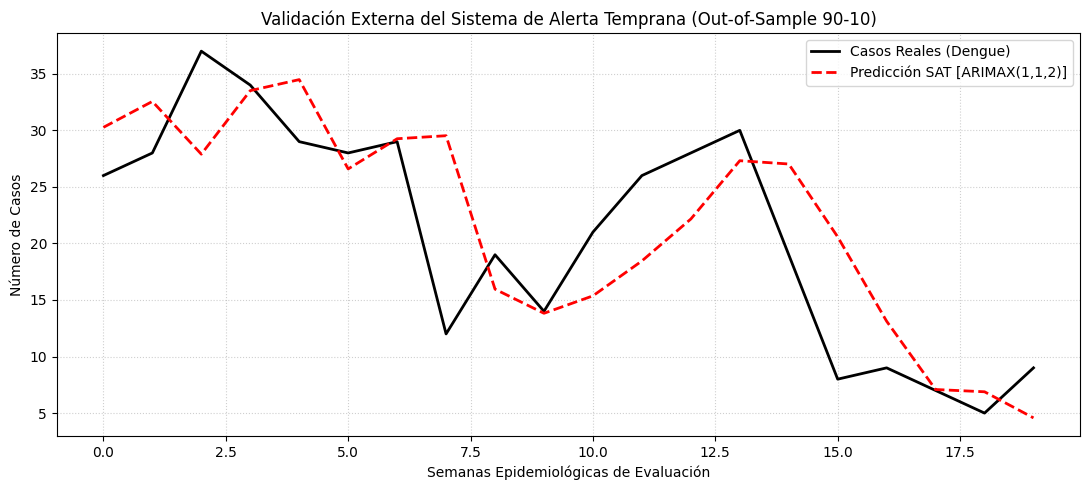

In [56]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

# =====================================================================
# 4. EXTRACCIÓN Y DIAGNÓSTICO DEL MODELO GANADOR: ARIMAX(1,1,2)
# =====================================================================
# Forzamos la ejecución limpia del Rolling Forecast solo para el ganador 
# para guardar sus vectores de predicción y residuos exactos

orden_ganador = (1, 1, 2)
predicciones_finales_test = []
valores_reales_finales_test = []
residuos_acumulados = []

print("\nGenerando diagnósticos y gráficos para el modelo ganador ARIMAX(1,1,2)...")

for t in range(split_point, len(df)):
    y_train_log = y_log.iloc[:t]
    y_test_real = y_original[t]
    
    X_train_raw = X_raw.iloc[:t]
    X_test_raw = X_raw.iloc[t:t+1]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    
    model = ARIMA(y_train_log, exog=X_train_scaled, order=orden_ganador)
    model_fit = model.fit()
    forecast_log = model_fit.forecast(steps=1, exog=X_test_scaled)
    
    predicciones_finales_test.append(np.expm1(forecast_log.iloc[0]))
    valores_reales_finales_test.append(y_test_real)
    residuos_acumulados.append(model_fit.resid.iloc[-1]) # Último residuo de la ventana

predicciones_finales_test = np.array(predicciones_finales_test)
valores_reales_finales_test = np.array(valores_reales_finales_test)
residuos_acumulados = np.array(residuos_acumulados)

# --- GRÁFICO 1: VALIDACIÓN DEL PRONÓSTICO ---
plt.figure(figsize=(11, 5))
plt.plot(valores_reales_finales_test, label='Casos Reales (Dengue)', color='black', linewidth=2)
plt.plot(predicciones_finales_test, label='Predicción SAT [ARIMAX(1,1,2)]', color='red', linestyle='--', linewidth=2)
plt.title('Validación Externa del Sistema de Alerta Temprana (Out-of-Sample 90-10)')
plt.xlabel('Semanas Epidemiológicas de Evaluación')
plt.ylabel('Número de Casos')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()



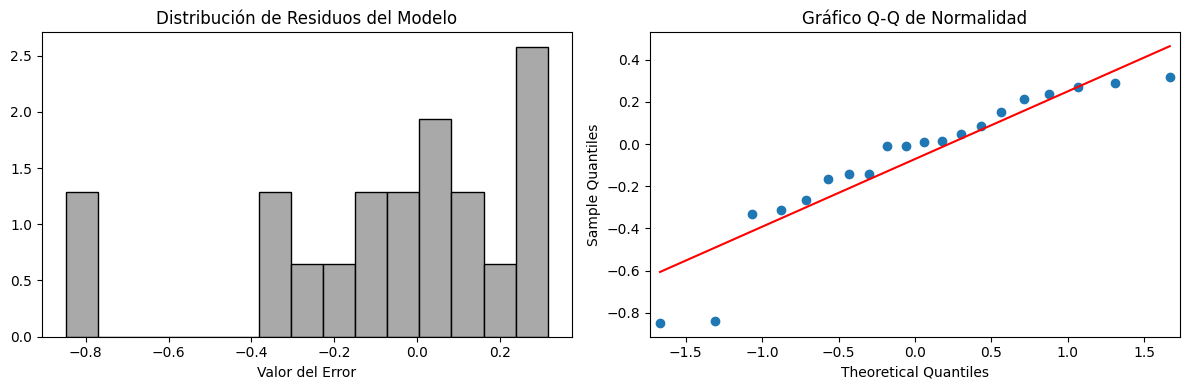

In [57]:
# --- GRÁFICO 2: DIAGNÓSTICO DE RESIDUOS ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Histograma
axes[0].hist(residuos_acumulados, bins=15, edgecolor='black', color='darkgray', density=True)
axes[0].set_title('Distribución de Residuos del Modelo')
axes[0].set_xlabel('Valor del Error')
# QQ-Plot
sm.qqplot(residuos_acumulados, line='s', ax=axes[1])
axes[1].set_title('Gráfico Q-Q de Normalidad')
plt.tight_layout()
plt.show()



In [8]:
# --- PRUEBA ESTADÍSTICA DE LJUNG-BOX ---
print("\n--- RESULTADO DE LA PRUEBA DE LJUNG-BOX ---")
lb_df = acorr_ljungbox(residuos_acumulados, lags=[10], return_df=True)
p_val = lb_df['lb_pvalue'].values[0]
print(lb_df)
if p_val > 0.05:
    print(f"p-value = {p_val:.4f} (> 0.05). ¡Éxito! Residuos sin autocorrelación (Ruido Blanco). Modelo validado.")
else:
    print(f"p-value = {p_val:.4f} (< 0.05). Advertencia: Queda estructura serial en los errores.")


--- RESULTADO DE LA PRUEBA DE LJUNG-BOX ---
     lb_stat  lb_pvalue
10  9.177277   0.515366
p-value = 0.5154 (> 0.05). ¡Éxito! Residuos sin autocorrelación (Ruido Blanco). Modelo validado.


## Gráfico del entrenamiento y testeo

Procesando datos y limpiando etiquetas temporales...


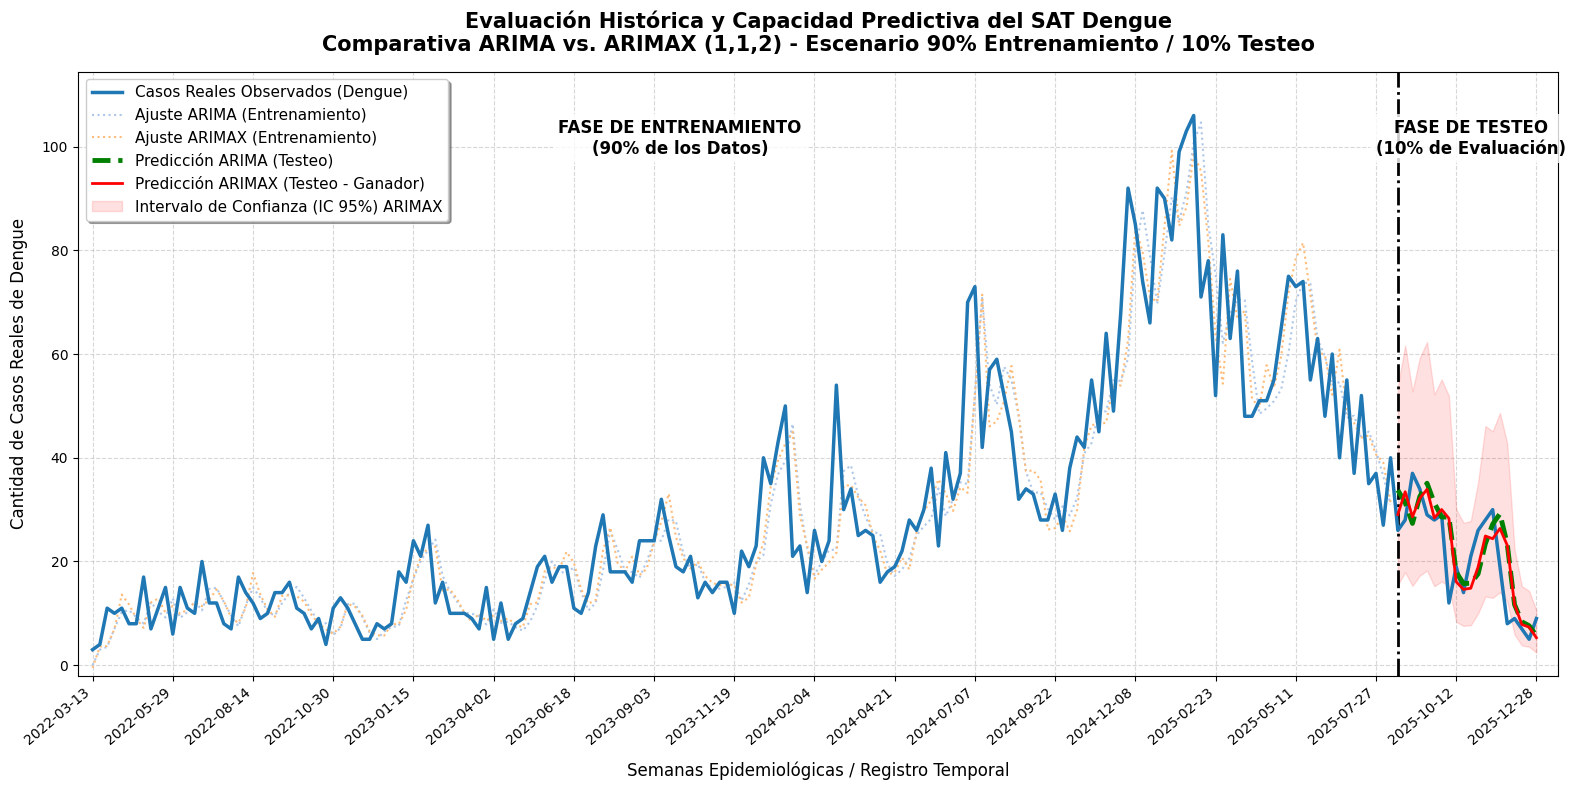

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. CARGA DE DATOS, REZAGOS Y CONFIGURACIÓN DE TIEMPO
# =====================================================================
ruta_bd = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_semanal_meteo_epi_2022-2025.xlsx"

df_original = pd.read_excel(ruta_bd)

col_dengue = 'casos_dengue'
col_hum = 'hum_esp'
col_temp = 'temp_min'
col_prec = 'prec'
col_lluvia = 'dias_lluvia'
col_sst = 'sst'
col_soi = 'soi'

# --- TRATAMIENTO DE FECHAS LIMPIAS (SIN HORA) ---
if 'fecha' in df_original.columns:
    # Convertimos a formato datetime y luego extraemos solo la fecha limpia (YYYY-MM-DD)
    df_original['eje_tiempo'] = pd.to_datetime(df_original['fecha']).dt.strftime('%Y-%m-%d')
elif 'semana' in df_original.columns:
    df_original['eje_tiempo'] = df_original['semana'].astype(str)
else:
    df_original['eje_tiempo'] = "S" + df_original.index.astype(str)

df = df_original[[col_dengue, 'eje_tiempo']].copy()

# Generamos rezagos
df['hum_esp_lag6'] = df_original[col_hum].shift(6)
df['temp_min_lag4'] = df_original[col_temp].shift(4)
df['prec_lag7'] = df_original[col_prec].shift(7)
df['lluvia_lag3'] = df_original[col_lluvia].shift(3)
df['sst_lag10'] = df_original[col_sst].shift(10)
df['soi_lag8'] = df_original[col_soi].shift(8)

df = df.dropna().reset_index(drop=True)

y_original = df[col_dengue].values
df['log_casos'] = np.log1p(df[col_dengue])

y_log = df['log_casos']
columnas_exog = ['hum_esp_lag6', 'temp_min_lag4', 'prec_lag7', 'lluvia_lag3', 'sst_lag10', 'soi_lag8']
X_raw = df[columnas_exog]
tiempos = df['eje_tiempo'].values  # Etiquetas limpias para el eje X

# =====================================================================
# 2. PROCESAMIENTO DE ESCENARIO 90-10 Y ROLLING FORECAST
# =====================================================================
porcentaje = 0.90
split_point = int(len(df) * porcentaje)
orden_ganador = (1, 1, 2)

pred_arima_test = []
pred_arimax_test = []
ic_arimax_lower = []
ic_arimax_upper = []

print("Procesando datos y limpiando etiquetas temporales...")

for t in range(split_point, len(df)):
    y_train_log = y_log.iloc[:t]
    
    # --- MODELO ARIMA ---
    model_arima = ARIMA(y_train_log, order=orden_ganador)
    res_arima = model_arima.fit()
    pred_arima_test.append(np.expm1(res_arima.forecast(steps=1).iloc[0]))
    
    # --- MODELO ARIMAX ---
    X_train_raw = X_raw.iloc[:t]
    X_test_raw = X_raw.iloc[t:t+1]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    
    model_arimax = ARIMA(y_train_log, exog=X_train_scaled, order=orden_ganador)
    res_arimax = model_arimax.fit()
    
    forecast_obj = res_arimax.get_forecast(steps=1, exog=X_test_scaled)
    pred_log = forecast_obj.predicted_mean.iloc[0]
    ci_matrix = forecast_obj.conf_int(alpha=0.05)
    
    pred_arimax_test.append(np.expm1(pred_log))
    ic_arimax_lower.append(np.expm1(ci_matrix.iloc[0, 0]))
    ic_arimax_upper.append(np.expm1(ci_matrix.iloc[0, 1]))
    
    if t == split_point:
        train_pred_arima = np.expm1(res_arima.fittedvalues)
        train_pred_arimax = np.expm1(res_arimax.fittedvalues)

pred_arima_test = np.array(pred_arima_test)
pred_arimax_test = np.array(pred_arimax_test)
ic_arimax_lower = np.array(ic_arimax_lower)
ic_arimax_upper = np.array(ic_arimax_upper)

# =====================================================================
# 3. GENERACIÓN DEL GRÁFICO REFINADO
# =====================================================================
plt.figure(figsize=(16, 8))

idx_total = np.arange(len(df))
idx_train = np.arange(split_point)
idx_test = np.arange(split_point, len(df))

# 1. Serie Real
plt.plot(idx_total, y_original, label='Casos Reales Observados (Dengue)', color='#1f77b4', linewidth=2.5, zorder=3)

# 2. Ajuste en Entrenamiento
plt.plot(idx_train, train_pred_arima, label='Ajuste ARIMA (Entrenamiento)', color='#aec7e8', linestyle=':', linewidth=1.5)
plt.plot(idx_train, train_pred_arimax, label='Ajuste ARIMAX (Entrenamiento)', color='#ffbb78', linestyle=':', linewidth=1.5)

# 3. Predicciones en Testeo (Modificamos grosores y zorder para que ambas resalten)
plt.plot(idx_test, pred_arima_test, label='Predicción ARIMA (Testeo)', color='green', linestyle='--', linewidth=3.5, zorder=4)
plt.plot(idx_test, pred_arimax_test, label='Predicción ARIMAX (Testeo - Ganador)', color='red', linestyle='-', linewidth=2.0, zorder=5)

# 4. Sombreado de Intervalo de Confianza
plt.fill_between(idx_test, ic_arimax_lower, ic_arimax_upper, color='red', alpha=0.12, label='Intervalo de Confianza (IC 95%) ARIMAX', zorder=2)

# 5. Línea de separación y textos informativos
plt.axvline(x=split_point, color='black', linestyle='-.', linewidth=2)
plt.text(split_point * 0.45, max(y_original) * 0.93, 'FASE DE ENTRENAMIENTO\n(90% de los Datos)', 
         horizontalalignment='center', fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
plt.text(split_point + (len(df) - split_point) * 0.5, max(y_original) * 0.93, 'FASE DE TESTEO\n(10% de Evaluación)', 
         horizontalalignment='center', fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# 6. Configuración del eje X con fechas cortas e intervalos balanceados
paso_etiquetas = max(1, len(df) // 18) 
plt.xticks(idx_total[::paso_etiquetas], tiempos[::paso_etiquetas], rotation=40, ha='right', fontsize=10)

plt.title('Evaluación Histórica y Capacidad Predictiva del SAT Dengue\nComparativa ARIMA vs. ARIMAX (1,1,2) - Escenario 90% Entrenamiento / 10% Testeo', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Semanas Epidemiológicas / Registro Temporal', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Casos Reales de Dengue', fontsize=12, labelpad=10)

plt.xlim(-2, len(df) + 2)
plt.ylim(-2, max(y_original) * 1.08)
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Gráfico del testeo

Generando predicciones y enfocando ventana de testeo...


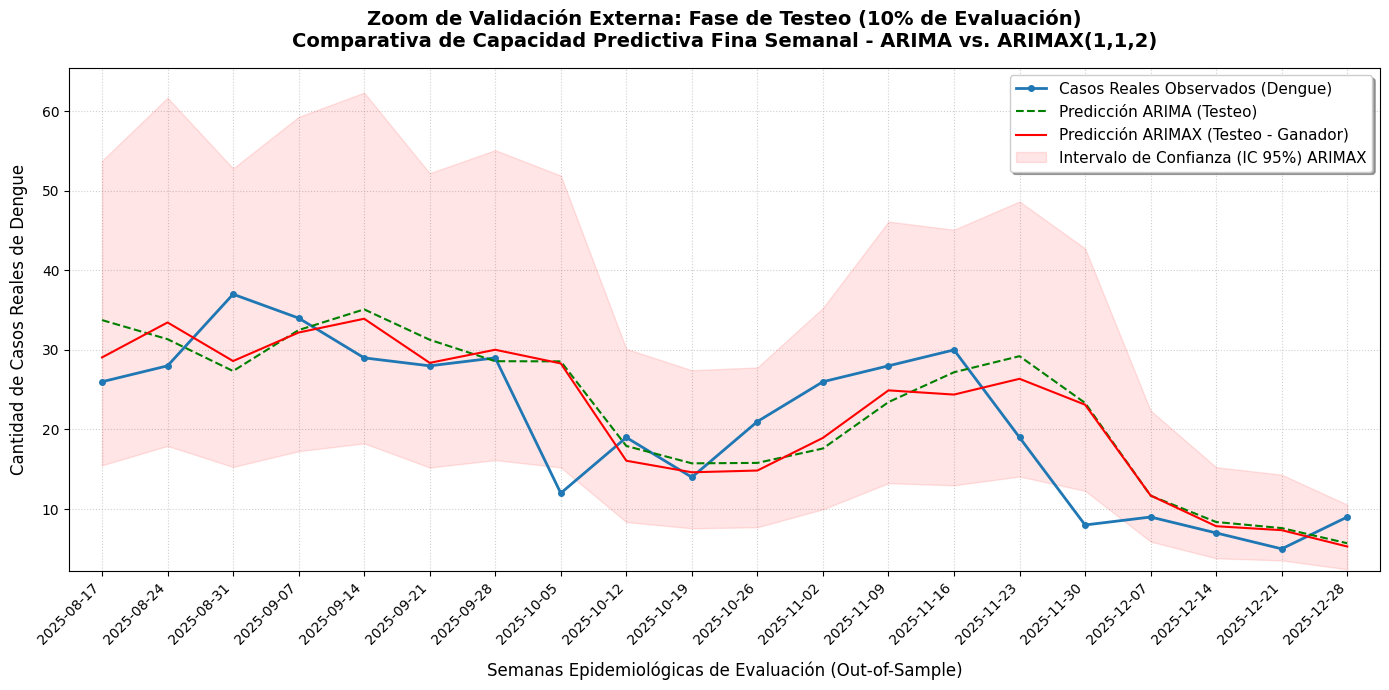

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. CARGA DE DATOS, REZAGOS Y CONFIGURACIÓN DE TIEMPO
# =====================================================================
ruta_bd = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_semanal_meteo_epi_2022-2025.xlsx"

df_original = pd.read_excel(ruta_bd)

col_dengue = 'casos_dengue'
col_hum = 'hum_esp'
col_temp = 'temp_min'
col_prec = 'prec'
col_lluvia = 'dias_lluvia'
col_sst = 'sst'
col_soi = 'soi'

# Tratamiento de fechas limpias (sin hora)
if 'fecha' in df_original.columns:
    df_original['eje_tiempo'] = pd.to_datetime(df_original['fecha']).dt.strftime('%Y-%m-%d')
elif 'semana' in df_original.columns:
    df_original['eje_tiempo'] = df_original['semana'].astype(str)
else:
    df_original['eje_tiempo'] = "S" + df_original.index.astype(str)

df = df_original[[col_dengue, 'eje_tiempo']].copy()

# Generamos rezagos
df['hum_esp_lag6'] = df_original[col_hum].shift(6)
df['temp_min_lag4'] = df_original[col_temp].shift(4)
df['prec_lag7'] = df_original[col_prec].shift(7)
df['lluvia_lag3'] = df_original[col_lluvia].shift(3)
df['sst_lag10'] = df_original[col_sst].shift(10)
df['soi_lag8'] = df_original[col_soi].shift(8)

df = df.dropna().reset_index(drop=True)

y_original = df[col_dengue].values
df['log_casos'] = np.log1p(df[col_dengue])

y_log = df['log_casos']
columnas_exog = ['hum_esp_lag6', 'temp_min_lag4', 'prec_lag7', 'lluvia_lag3', 'sst_lag10', 'soi_lag8']
X_raw = df[columnas_exog]
tiempos = df['eje_tiempo'].values  

# =====================================================================
# 2. PROCESAMIENTO DE ROLLING FORECAST (ESCENARIO 90-10)
# =====================================================================
porcentaje = 0.90
split_point = int(len(df) * porcentaje)
orden_ganador = (1, 1, 2)

pred_arima_test = []
pred_arimax_test = []
ic_arimax_lower = []
ic_arimax_upper = []

print("Generando predicciones y enfocando ventana de testeo...")

for t in range(split_point, len(df)):
    y_train_log = y_log.iloc[:t]
    
    # --- MODELO ARIMA ---
    model_arima = ARIMA(y_train_log, order=orden_ganador)
    res_arima = model_arima.fit()
    pred_arima_test.append(np.expm1(res_arima.forecast(steps=1).iloc[0]))
    
    # --- MODELO ARIMAX ---
    X_train_raw = X_raw.iloc[:t]
    X_test_raw = X_raw.iloc[t:t+1]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    
    model_arimax = ARIMA(y_train_log, exog=X_train_scaled, order=orden_ganador)
    res_arimax = model_arimax.fit()
    
    forecast_obj = res_arimax.get_forecast(steps=1, exog=X_test_scaled)
    pred_log = forecast_obj.predicted_mean.iloc[0]
    ci_matrix = forecast_obj.conf_int(alpha=0.05)
    
    pred_arimax_test.append(np.expm1(pred_log))
    ic_arimax_lower.append(np.expm1(ci_matrix.iloc[0, 0]))
    ic_arimax_upper.append(np.expm1(ci_matrix.iloc[0, 1]))

pred_arima_test = np.array(pred_arima_test)
pred_arimax_test = np.array(pred_arimax_test)
ic_arimax_lower = np.array(ic_arimax_lower)
ic_arimax_upper = np.array(ic_arimax_upper)

# Valores reales del segmento de testeo
valores_reales_test = y_original[split_point:]
tiempos_test = tiempos[split_point:]
idx_test = np.arange(len(valores_reales_test))

# =====================================================================
# 3. GENERACIÓN DEL GRÁFICO EXCLUSIVO DE TESTEO (ZOOM)
# =====================================================================
plt.figure(figsize=(14, 7))

# 1. Curvas con líneas estilizadas y más delgadas (foco exclusivo en el testeo)
plt.plot(idx_test, valores_reales_test, label='Casos Reales Observados (Dengue)', color='#1f77b4', linewidth=2.0, marker='o', markersize=4, zorder=3)
plt.plot(idx_test, pred_arima_test, label='Predicción ARIMA (Testeo)', color='green', linestyle='--', linewidth=1.5, zorder=4)
plt.plot(idx_test, pred_arimax_test, label='Predicción ARIMAX (Testeo - Ganador)', color='red', linestyle='-', linewidth=1.5, zorder=5)

# 2. Sombreado del Intervalo de Confianza (IC 95%)
plt.fill_between(idx_test, ic_arimax_lower, ic_arimax_upper, color='red', alpha=0.10, label='Intervalo de Confianza (IC 95%) ARIMAX', zorder=2)

# 3. Ajustes de Ejes y Fechas Cortas
plt.xticks(idx_test, tiempos_test, rotation=45, ha='right', fontsize=10)

# Títulos y formato académico
plt.title('Zoom de Validación Externa: Fase de Testeo (10% de Evaluación)\nComparativa de Capacidad Predictiva Fina Semanal - ARIMA vs. ARIMAX(1,1,2)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Semanas Epidemiológicas de Evaluación (Out-of-Sample)', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Casos Reales de Dengue', fontsize=12, labelpad=10)

plt.xlim(-0.5, len(valores_reales_test) - 0.5)
plt.ylim(min(min(valores_reales_test), min(ic_arimax_lower)) * 0.9, max(max(valores_reales_test), max(ic_arimax_upper)) * 1.05)

plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Predicciones

In [16]:
import numpy as np
import pandas as pd
import os
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# 1. CARGA DE DATOS, REZAGOS Y CONFIGURACIÓN DE TIEMPO
# =====================================================================
ruta_bd = r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\datos_consolidados\1_datos_semana_epi_meteo\datos_semanal_meteo_epi_2022-2025.xlsx"

df_original = pd.read_excel(ruta_bd)

col_dengue = 'casos_dengue'
col_hum = 'hum_esp'
col_temp = 'temp_min'
col_prec = 'prec'
col_lluvia = 'dias_lluvia'
col_sst = 'sst'
col_soi = 'soi'

# Formatear fechas limpias (sin hora)
if 'fecha' in df_original.columns:
    df_original['eje_tiempo'] = pd.to_datetime(df_original['fecha']).dt.strftime('%Y-%m-%d')
elif 'semana' in df_original.columns:
    df_original['eje_tiempo'] = df_original['semana'].astype(str)
else:
    df_original['eje_tiempo'] = "S" + df_original.index.astype(str)

df = df_original[[col_dengue, 'eje_tiempo']].copy()

# Generamos rezagos
df['hum_esp_lag6'] = df_original[col_hum].shift(6)
df['temp_min_lag4'] = df_original[col_temp].shift(4)
df['prec_lag7'] = df_original[col_prec].shift(7)
df['lluvia_lag3'] = df_original[col_lluvia].shift(3)
df['sst_lag10'] = df_original[col_sst].shift(10)
df['soi_lag8'] = df_original[col_soi].shift(8)

df = df.dropna().reset_index(drop=True)

y_original = df[col_dengue].values
df['log_casos'] = np.log1p(df[col_dengue])

y_log = df['log_casos']
columnas_exog = ['hum_esp_lag6', 'temp_min_lag4', 'prec_lag7', 'lluvia_lag3', 'sst_lag10', 'soi_lag8']
X_raw = df[columnas_exog]
tiempos = df['eje_tiempo'].values  

# =====================================================================
# 2. PROCESAMIENTO DE ROLLING FORECAST (ESCENARIO 90-10)
# =====================================================================
porcentaje = 0.90
split_point = int(len(df) * porcentaje)
orden_ganador = (1, 1, 2)

fechas_test = []
reales_test = []
preds_arima = []
preds_arimax = []

print("Calculando predicciones y errores semana a semana...")

for t in range(split_point, len(df)):
    y_train_log = y_log.iloc[:t]
    
    # --- MODELO ARIMA ---
    model_arima = ARIMA(y_train_log, order=orden_ganador)
    res_arima = model_arima.fit()
    pred_arima_real = np.expm1(res_arima.forecast(steps=1).iloc[0])
    
    # --- MODELO ARIMAX ---
    X_train_raw = X_raw.iloc[:t]
    X_test_raw = X_raw.iloc[t:t+1]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_raw)
    X_test_scaled = scaler.transform(X_test_raw)
    
    model_arimax = ARIMA(y_train_log, exog=X_train_scaled, order=orden_ganador)
    res_arimax = model_arimax.fit()
    pred_arimax_real = np.expm1(res_arimax.forecast(steps=1, exog=X_test_scaled).iloc[0])
    
    # Guardar registros de la semana actual
    fechas_test.append(tiempos[t])
    reales_test.append(y_original[t])
    preds_arima.append(pred_arima_real)
    preds_arimax.append(pred_arimax_real)

# =====================================================================
# 3. CONSOLIDACIÓN DE RESULTADOS Y CÁLCULO DE ERRORES
# =====================================================================
df_tabla = pd.DataFrame({
    'Fecha / Semana': fechas_test,
    'Casos Reales': reales_test,
    'Predicción ARIMA': np.round(preds_arima, 2),
    'Predicción ARIMAX': np.round(preds_arimax, 2)
})

# Cálculo del error absoluto individual (Magnitud del fallo en número de personas)
df_tabla['Error Abs ARIMA'] = np.round(np.abs(df_tabla['Casos Reales'] - df_tabla['Predicción ARIMA']), 2)
df_tabla['Error Abs ARIMAX'] = np.round(np.abs(df_tabla['Casos Reales'] - df_tabla['Predicción ARIMAX']), 2)

# Columna comparativa: ¿Cuál modelo funcionó mejor en esta semana específica?
df_tabla['Mejor Modelo'] = np.where(df_tabla['Error Abs ARIMAX'] < df_tabla['Error Abs ARIMA'], 'ARIMAX', 'ARIMA')
# Si empatan en error
df_tabla.loc[df_tabla['Error Abs ARIMAX'] == df_tabla['Error Abs ARIMA'], 'Mejor Modelo'] = 'Empate'

# Imprimir la tabla en la consola organizada de forma cronológica
print("\n================ TABLA DE PREDICCIONES Y ERRORES (FASE TESTEO) ================")
print(df_tabla.to_string(index=False))

# =====================================================================
# 4. EXPORTACIÓN AUTOMÁTICA A EXCEL
# =====================================================================
carpeta_salida = os.path.dirname(ruta_bd)
ruta_salida_excel = os.path.join(carpeta_salida, "Resultados_Predicciones_Testeo.xlsx")
df_tabla.to_excel(ruta_salida_excel, index=False)

print(f"\n[ÉXITO] Archivo de Excel guardado en:\n--> {ruta_salida_excel}")

Calculando predicciones y errores semana a semana...

================ TABLA DE PREDICCIONES Y ERRORES (FASE TESTEO) ================
Fecha / Semana  Casos Reales  Predicción ARIMA  Predicción ARIMAX  Error Abs ARIMA  Error Abs ARIMAX Mejor Modelo
    2025-08-17            26             33.75              29.06             7.75              3.06       ARIMAX
    2025-08-24            28             31.35              33.45             3.35              5.45        ARIMA
    2025-08-31            37             27.34              28.60             9.66              8.40       ARIMAX
    2025-09-07            34             32.49              32.18             1.51              1.82        ARIMA
    2025-09-14            29             35.10              33.92             6.10              4.92       ARIMAX
    2025-09-21            28             31.28              28.37             3.28              0.37       ARIMAX
    2025-09-28            29             28.58              30.02   